# فاز دوم — مقایسه و اعتبارسنجی خوشه‌بندی

تمام اعداد مستقیما از artifactهای pipeline خوانده می‌شوند.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
summary=json.loads((ROOT/'artifacts/phase2_run_summary.json').read_text(encoding='utf-8'))
summary['elapsed_seconds']

177.27065580000635

## انتخاب k و الگوریتم‌های partitioning

In [2]:
pd.read_csv(ROOT/'reports/tables/phase2_k_selection_synthesis.csv').sort_values('selection_rank_sum')[['k','silhouette','davies_bouldin','calinski_harabasz','mean','selection_rank_sum']]

,k,silhouette,davies_bouldin,calinski_harabasz,mean,selection_rank_sum
0,2,0.195354,2.349851,723.286371,0.918568,11.0
1,3,0.118922,2.327580,597.678510,0.942173,11.0
3,5,0.115592,2.109872,500.305059,0.916612,11.0
4,6,0.105534,2.111432,473.295358,0.915028,16.0
2,4,0.110474,2.274217,534.845803,0.889441,17.0
5,7,0.079078,2.351985,421.898160,0.741295,27.0
9,12,0.076134,2.251159,285.315471,0.747614,28.0
7,9,0.075908,2.192522,340.417833,0.589696,30.0
6,8,0.076584,2.465221,383.365647,0.691527,32.0
8,10,0.072807,2.388344,319.262339,0.667761,37.0


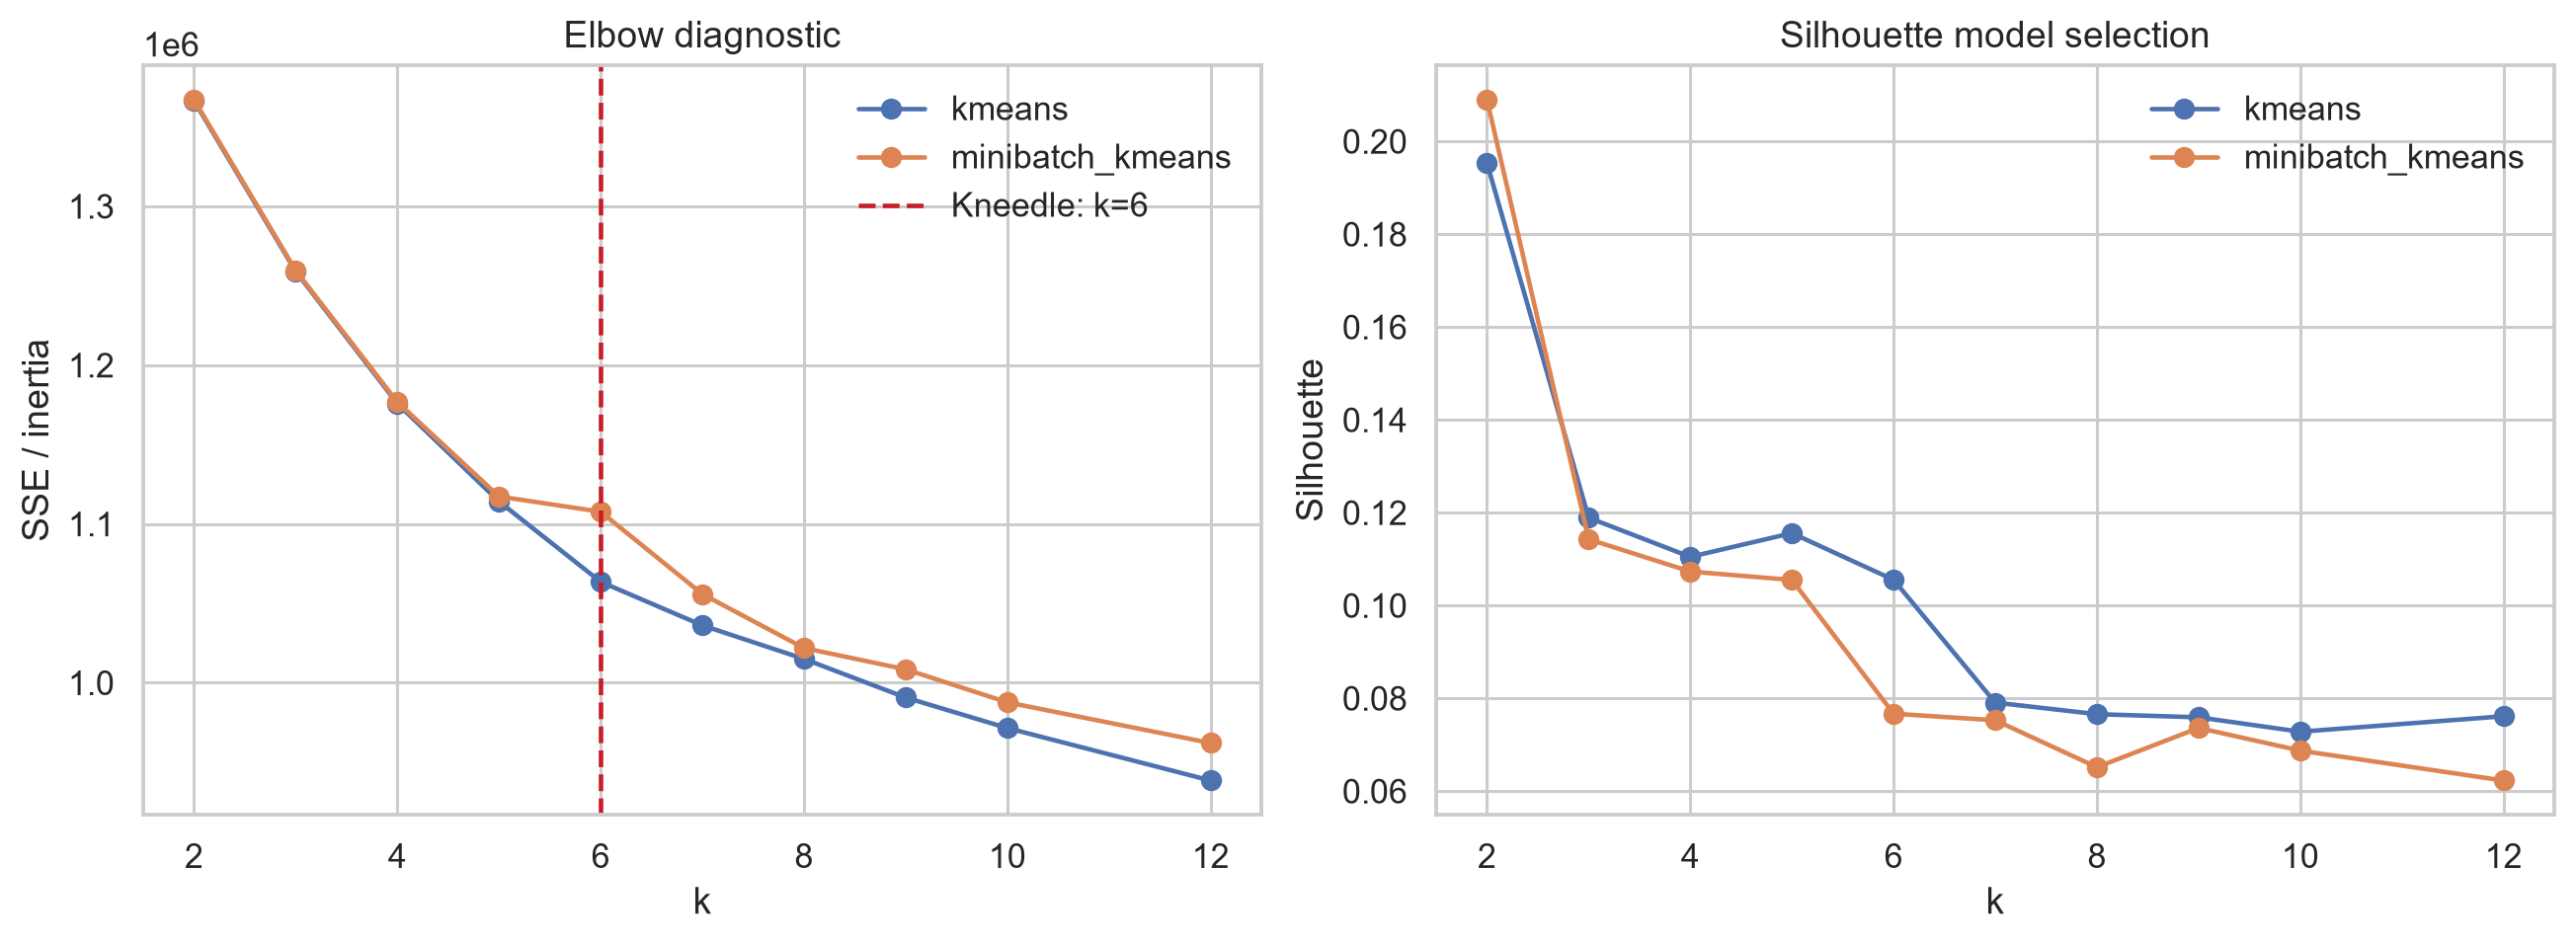

In [3]:
display(Image(filename=ROOT/'reports/figures/phase2_partitioning_selection.png', width=900))

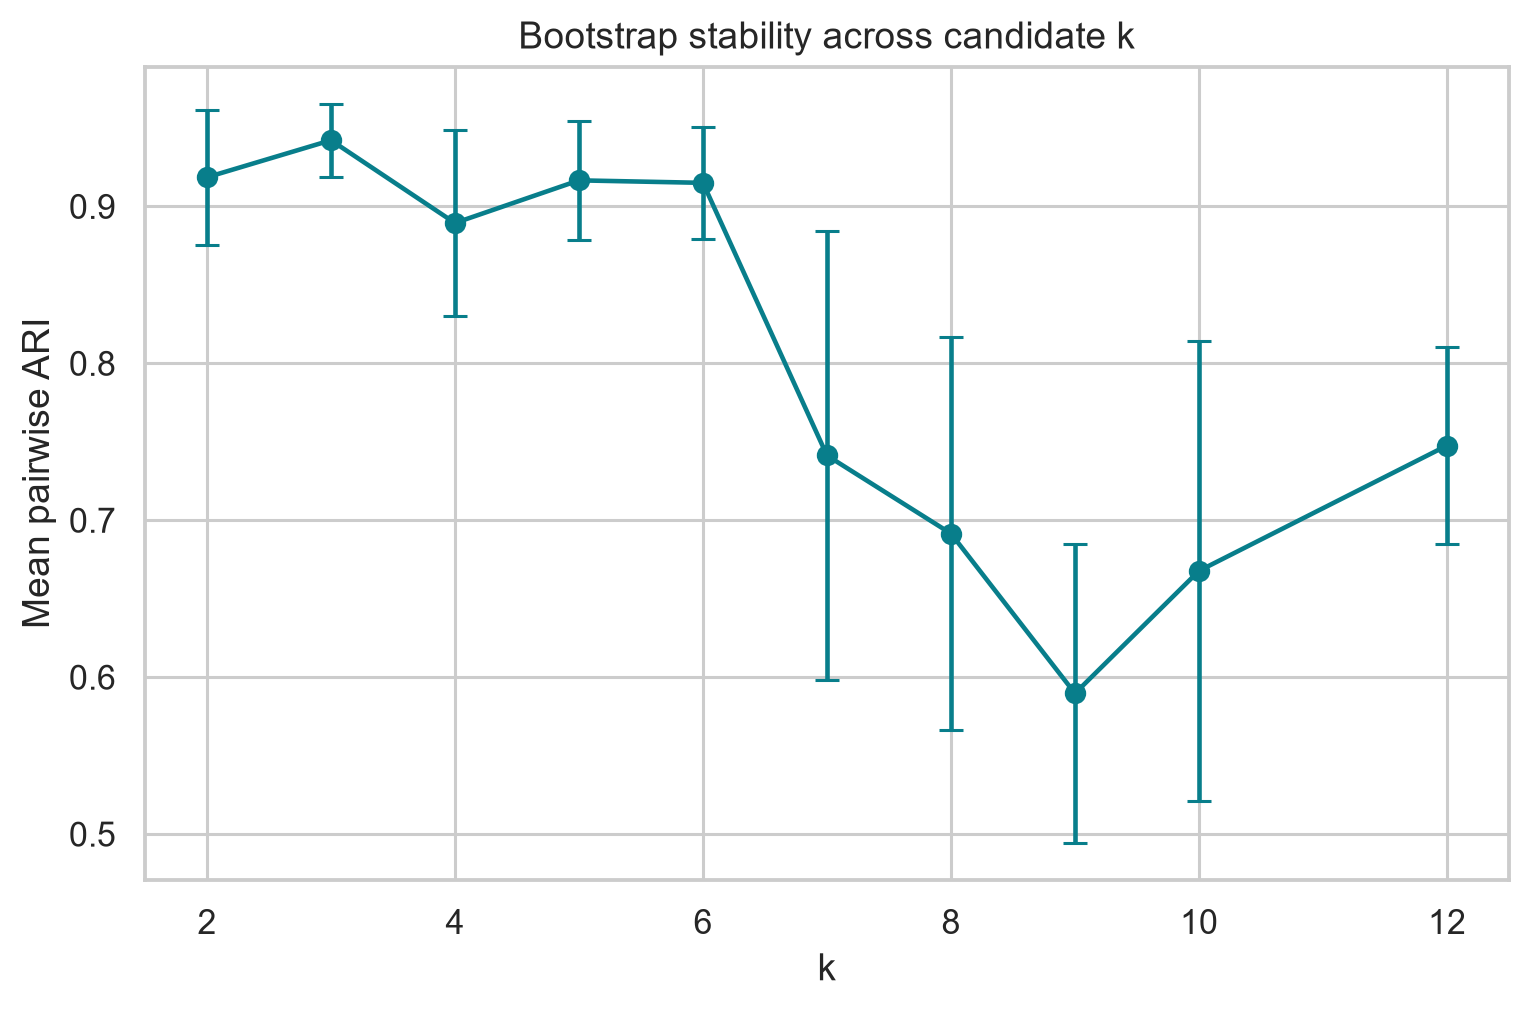

In [4]:
display(Image(filename=ROOT/'reports/figures/phase2_bootstrap_k_stability.png', width=800))

## مقایسه خانواده‌های مدل

In [5]:
scores=pd.read_csv(ROOT/'reports/tables/phase2_model_family_scores.csv')
scores.query('minimum_cluster_fraction >= 0.02 and silhouette == silhouette').sort_values('silhouette',ascending=False).head(15)[['family','algorithm','k_requested','silhouette','davies_bouldin','minimum_cluster_fraction','noise_fraction']]

,family,algorithm,k_requested,silhouette,davies_bouldin,minimum_cluster_fraction,noise_fraction
57,model_based,gmm_tied,2.0,0.241126,1.900063,0.091333,0.0
28,hierarchical,agglomerative_ward,2.0,0.211746,2.366467,0.170333,0.0
0,partitioning,kmeans,2.0,0.191427,2.358146,0.228667,0.0
43,model_based,gmm_spherical,2.0,0.154236,2.920656,0.341000,0.0
72,spectral,spectral_nearest_neighbors,3.0,0.121307,2.007333,0.065333,0.0
3,partitioning,kmeans,5.0,0.120338,2.060465,0.080333,0.0
1,partitioning,kmeans,3.0,0.118942,2.313449,0.198000,0.0
73,spectral,spectral_nearest_neighbors,4.0,0.118049,2.066330,0.064333,0.0
2,partitioning,kmeans,4.0,0.112631,2.221491,0.108000,0.0
44,model_based,gmm_spherical,3.0,0.111374,2.327191,0.208333,0.0


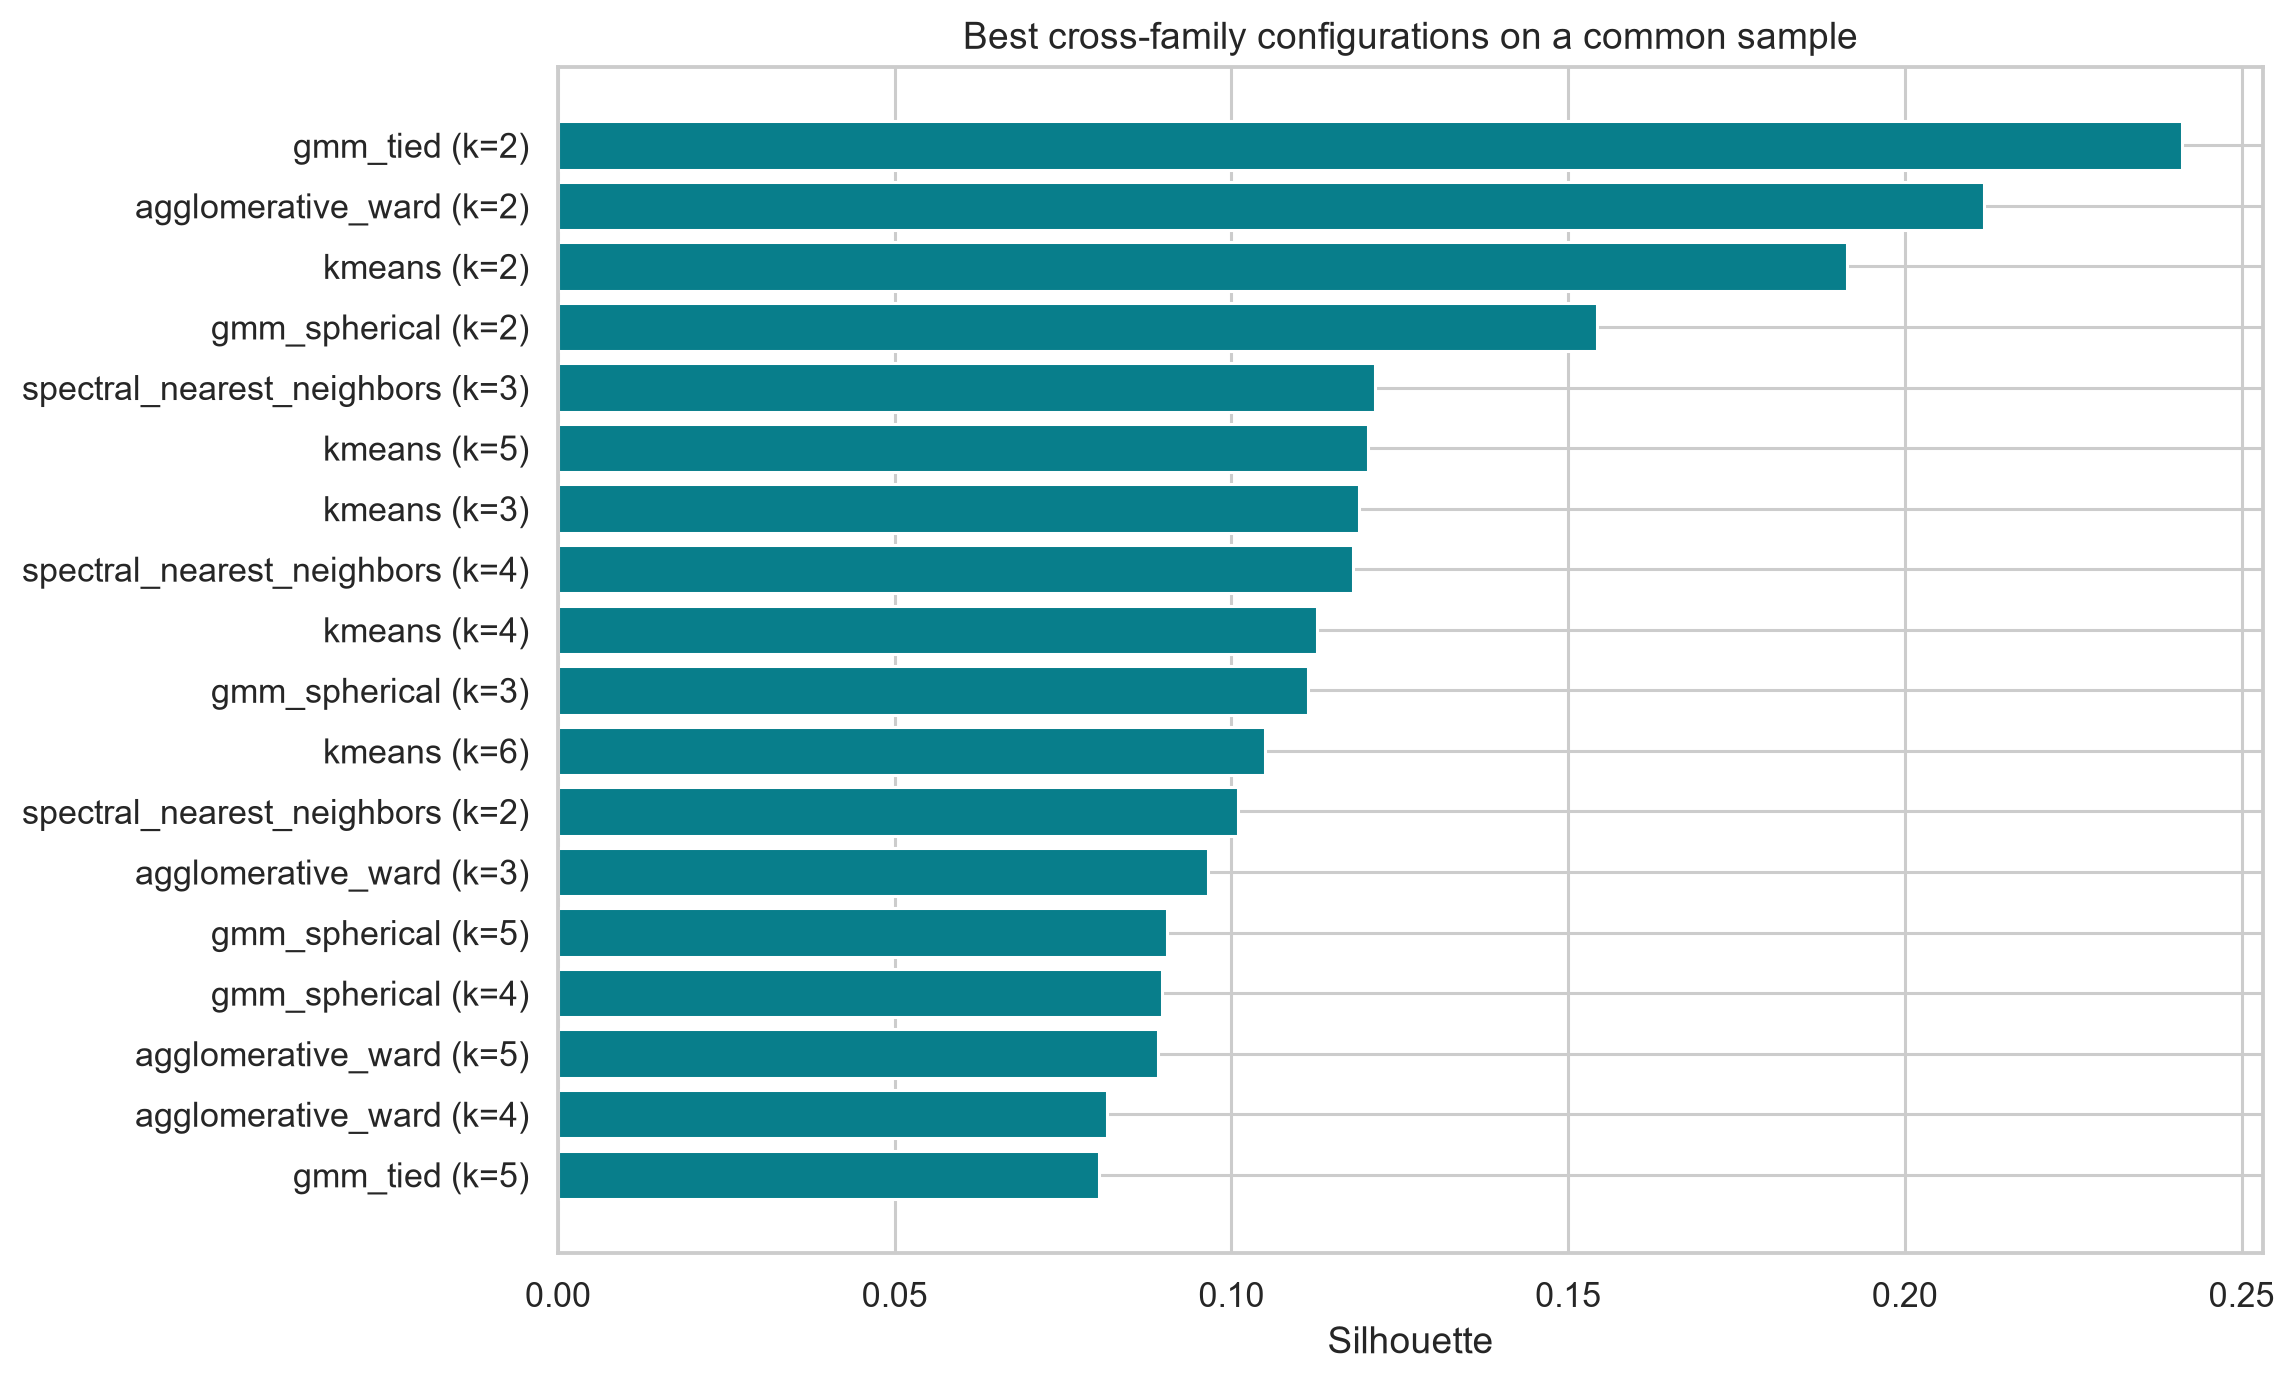

In [6]:
display(Image(filename=ROOT/'reports/figures/phase2_family_silhouette_comparison.png', width=900))

## GMM، روش‌های چگالی و سلسله‌مراتبی

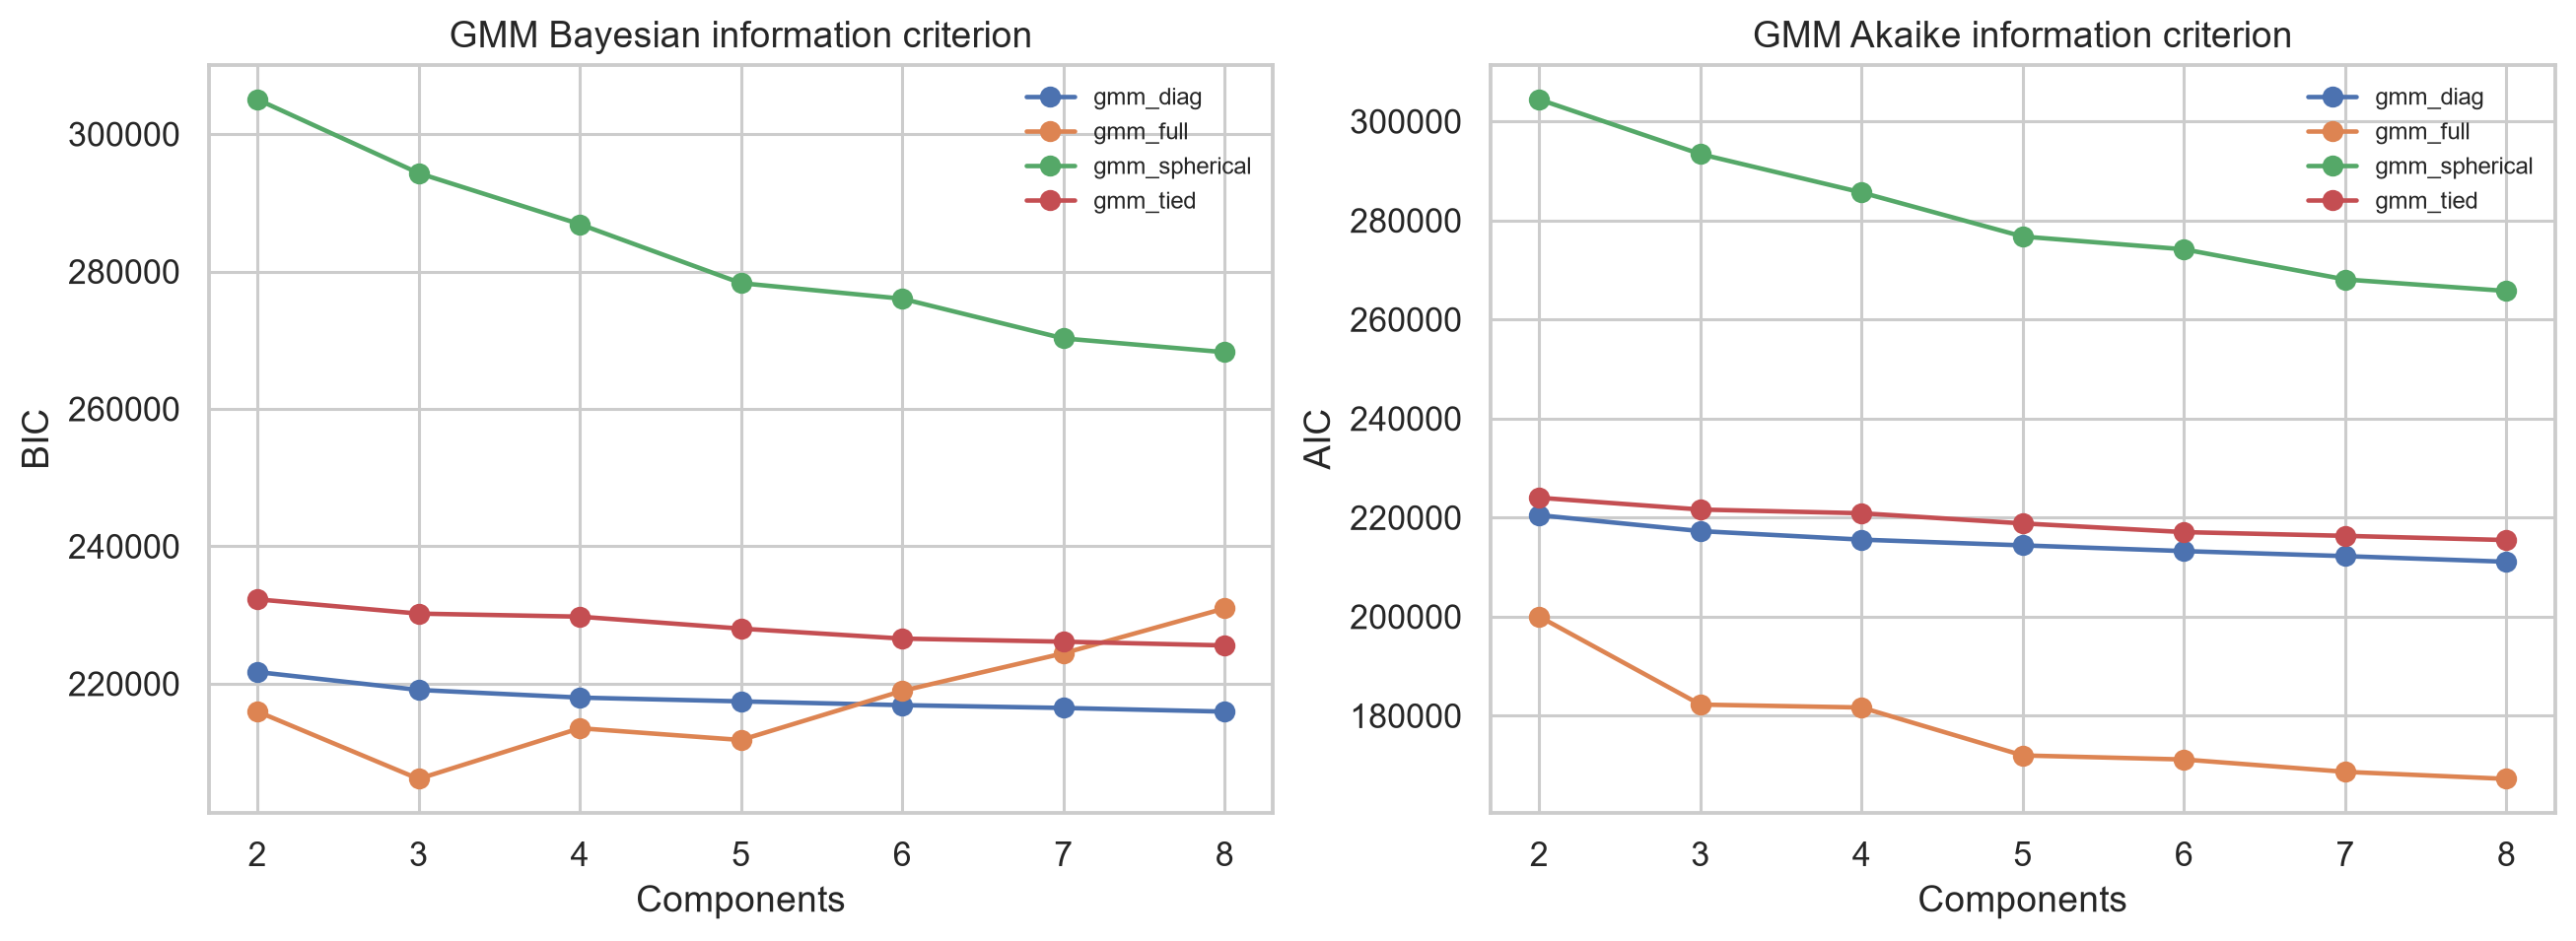

In [7]:
display(Image(filename=ROOT/'reports/figures/phase2_gmm_information_criteria.png', width=900))

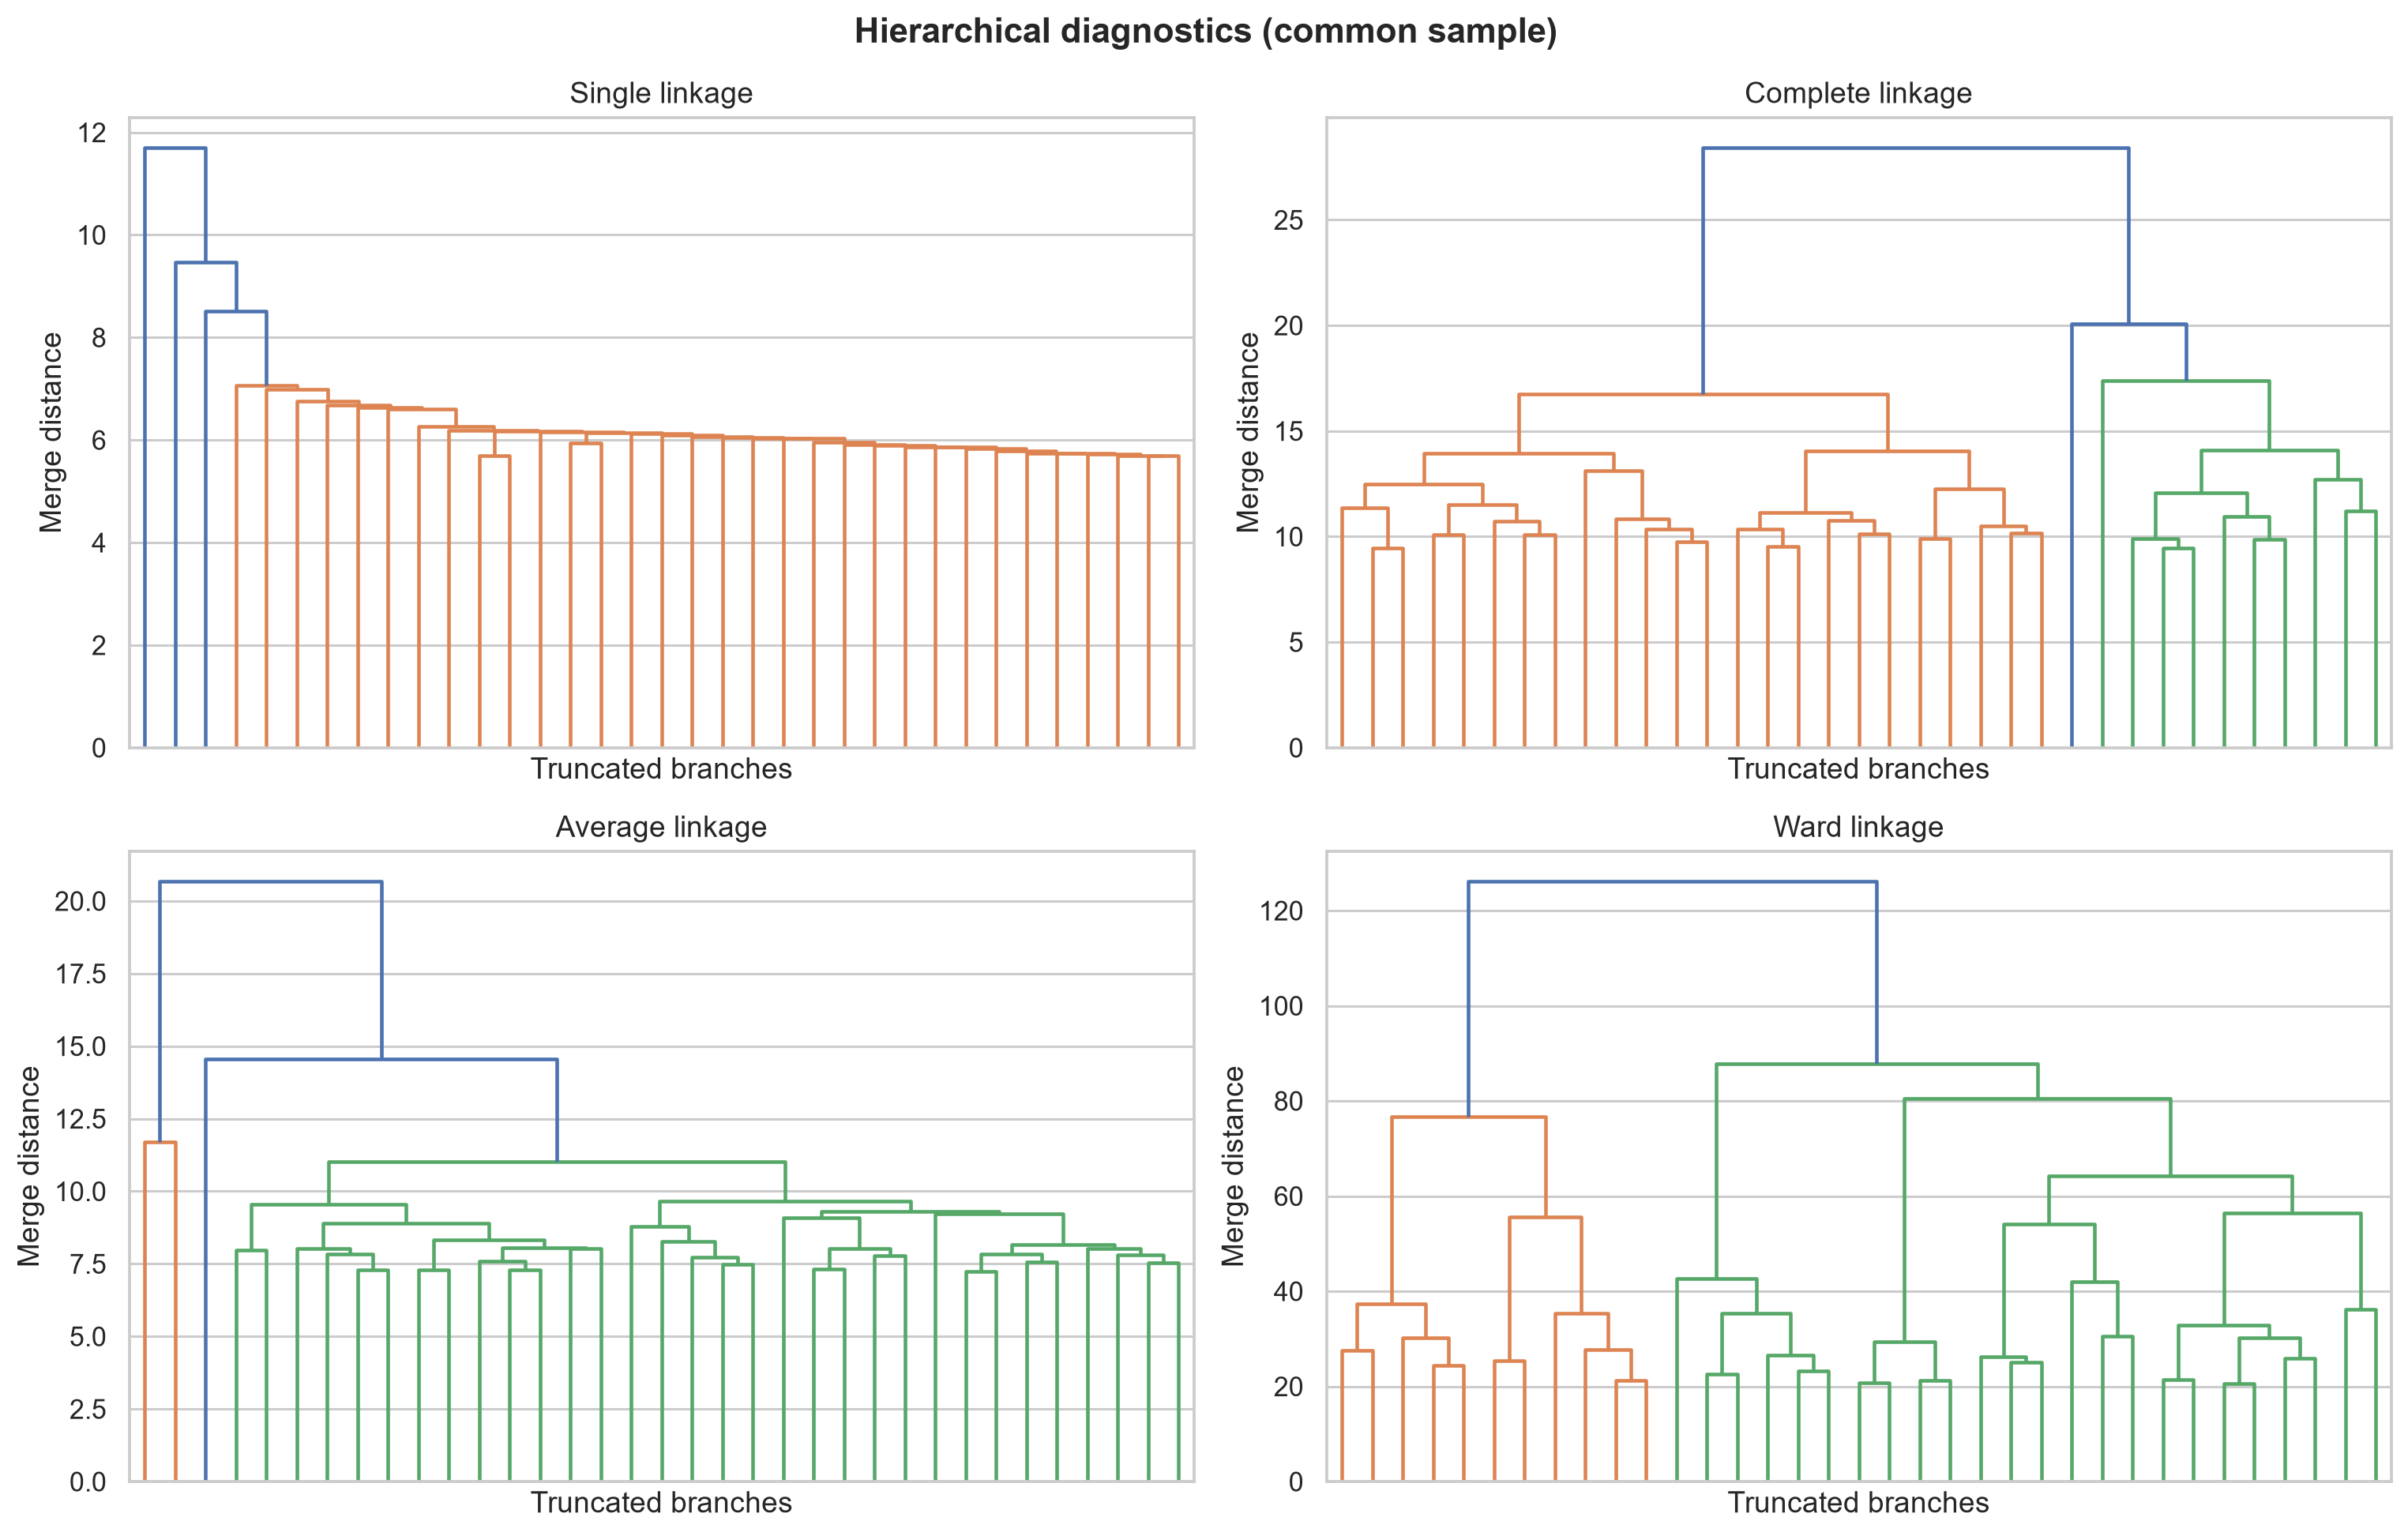

In [8]:
display(Image(filename=ROOT/'reports/figures/phase2_hierarchical_dendrograms.png', width=950))

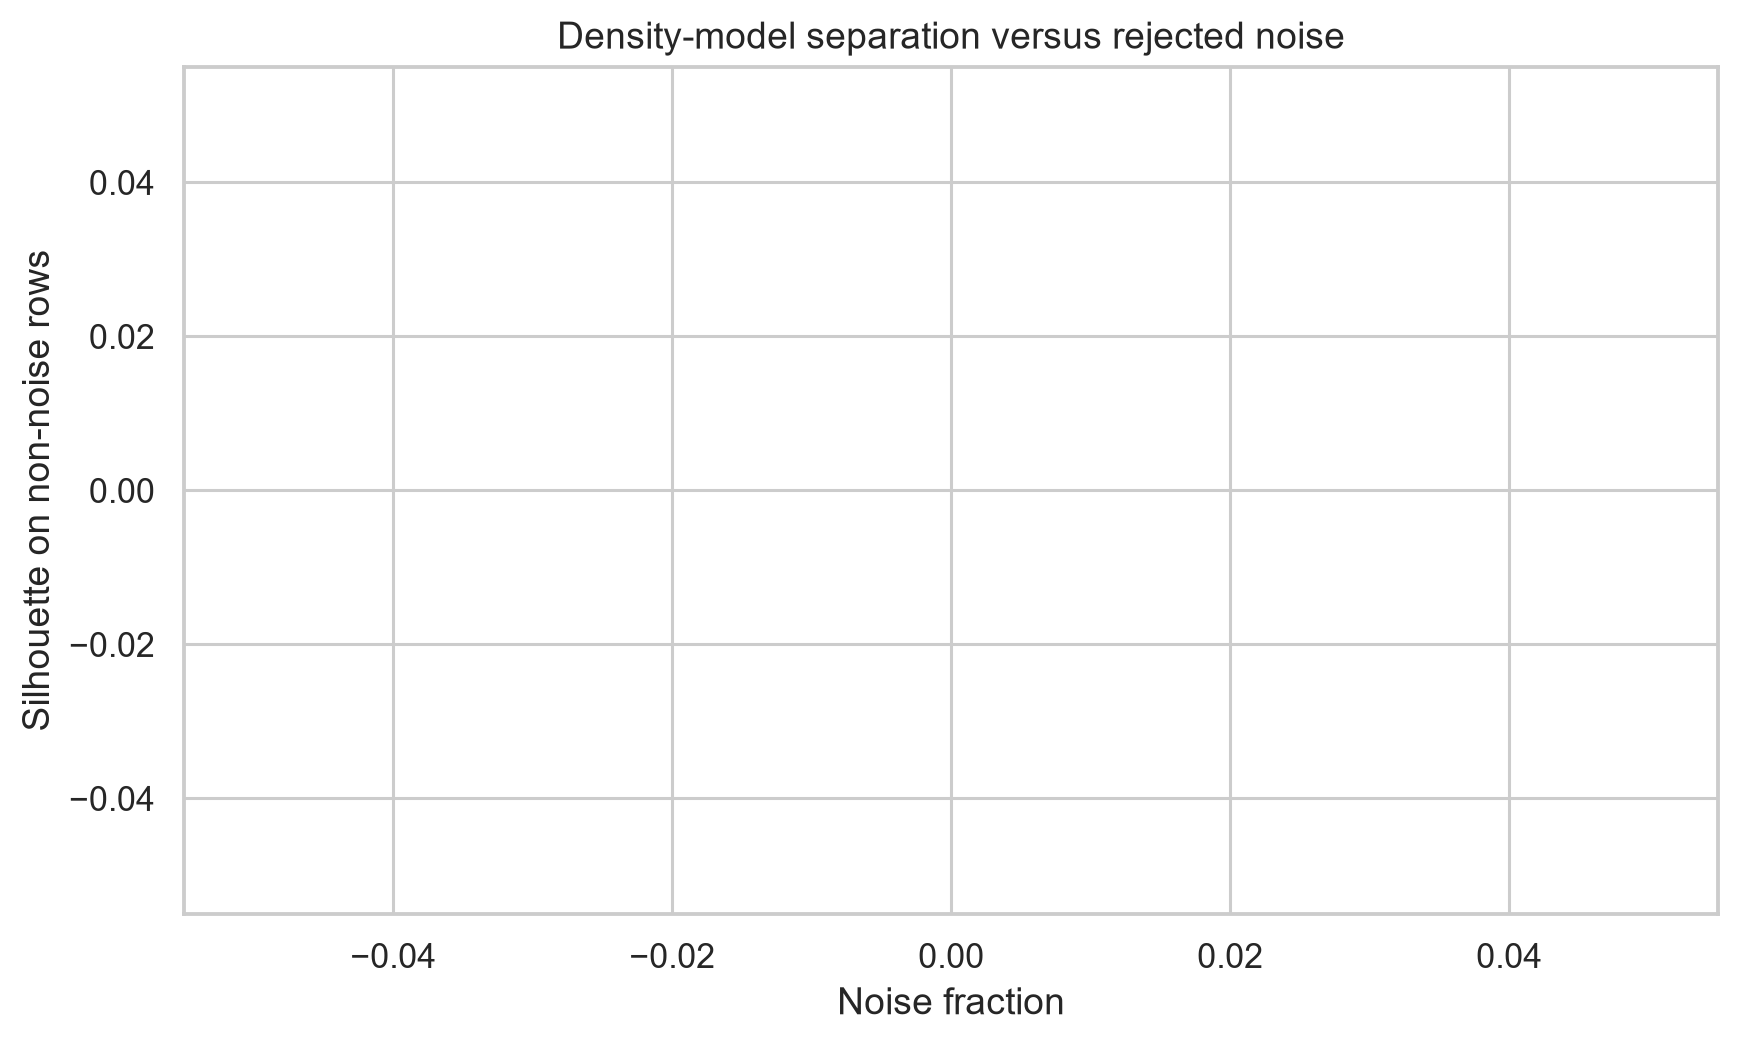

In [9]:
display(Image(filename=ROOT/'reports/figures/phase2_density_tradeoff.png', width=800))

## توافق، پایداری و محدودیت نتیجه

In [10]:
pd.read_csv(ROOT/'reports/tables/phase2_algorithm_agreement.csv')

,candidate_a,candidate_b,adjusted_rand_index
0,kmeans,agglomerative_ward,0.610513
1,kmeans,gmm_full_k3,0.082278
2,kmeans,spectral_k3,0.351064
3,agglomerative_ward,gmm_full_k3,0.021106
4,agglomerative_ward,spectral_k3,0.329901
5,gmm_full_k3,spectral_k3,0.043589


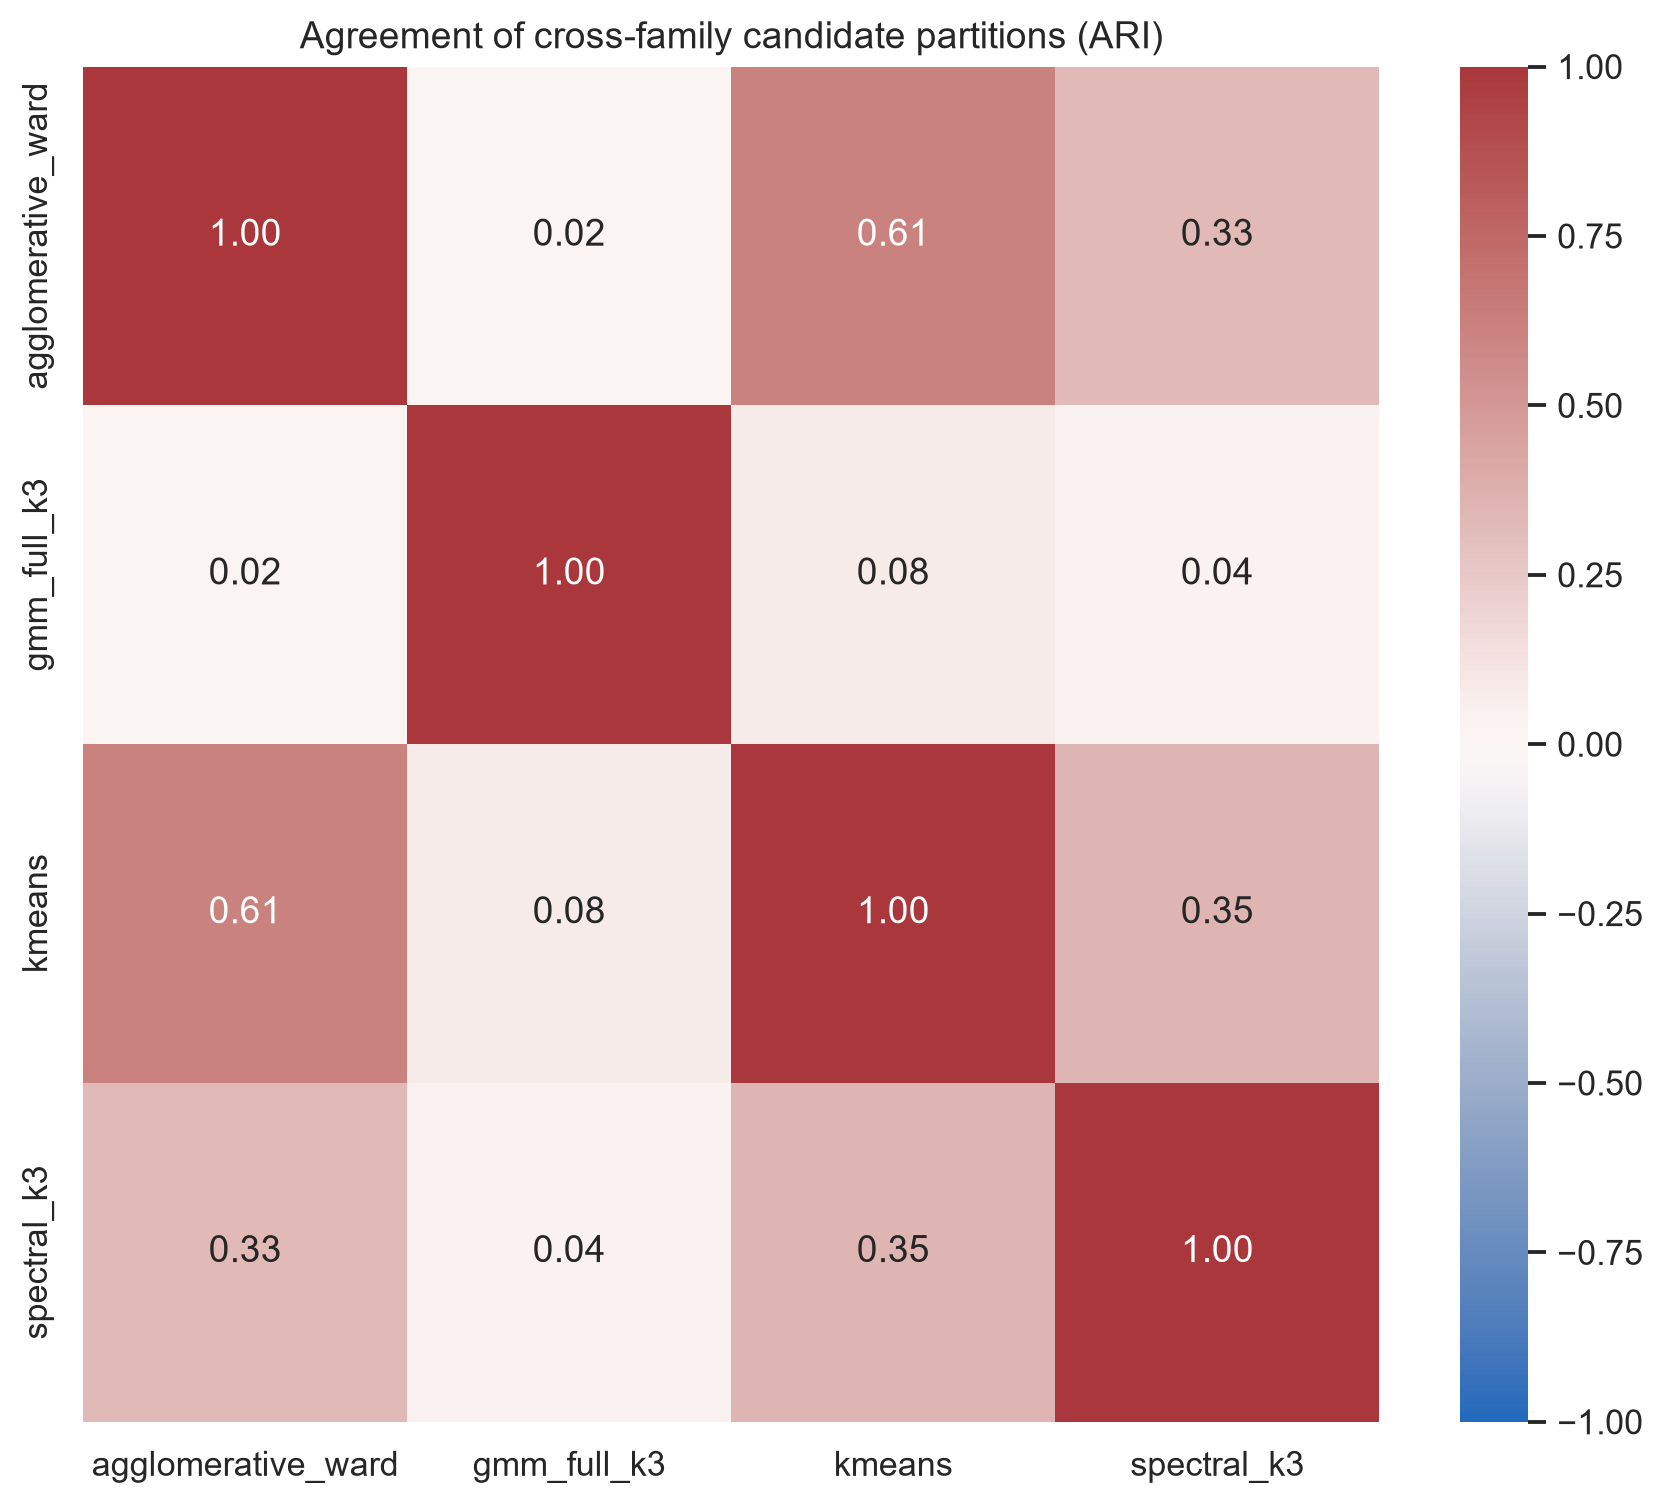

In [11]:
display(Image(filename=ROOT/'reports/figures/phase2_algorithm_agreement.png', width=800))

In [12]:
pd.read_csv(ROOT/'reports/tables/phase2_proxy_label_metrics.csv')

,proxy,normalized_mutual_information,categories,interpretation
0,DevType,0.009289,35,association only; proxy is not ground truth
1,EdLevel,0.002192,9,association only; proxy is not ground truth
2,Employment,0.012534,103,association only; proxy is not ground truth
3,RemoteWork,0.001006,4,association only; proxy is not ground truth
4,AISelect,0.003921,4,association only; proxy is not ground truth


نتیجه محافظه‌کارانه: ساختار واقعی اما هم‌پوشان است. k=2 مرجع عملیاتی است، k=3 پایدارترین bootstrap و انتخاب BIC است، و kهای 6 و 7 به‌ترتیب توسط elbow و Gap پیشنهاد می‌شوند. بنابراین فاز سوم از consensus و تحلیل پروفایل برای حل این اختلاف استفاده می‌کند.